In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [10]:
image_size= 256
batch_size= 32
channel=3

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -o -q "/content/drive/MyDrive/Plants.zip" -d "/content/dataset"

In [5]:
datast= tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/Plants", # Corrected path to include the 'Plants' directory
    shuffle= True,
    image_size= (image_size,image_size),
    batch_size= batch_size
)

Found 1904 files belonging to 3 classes.


In [6]:
class_names = datast.class_names # Corrected attribute name to 'class_names'
display(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [7]:
len(datast)

60

In [8]:
60*32

1920

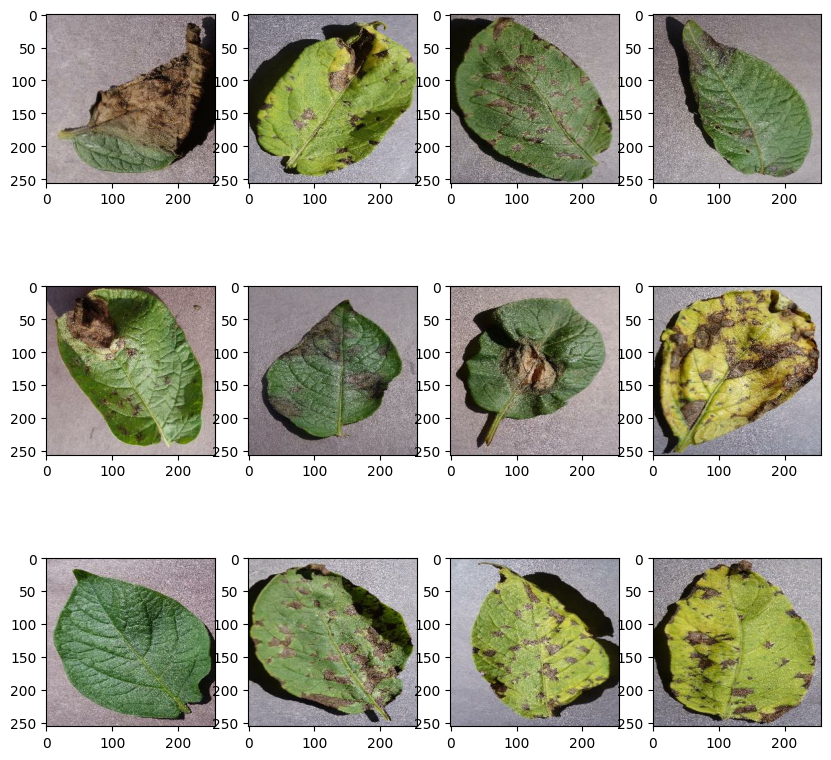

In [9]:
for image_batch, labels_batch in datast.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))

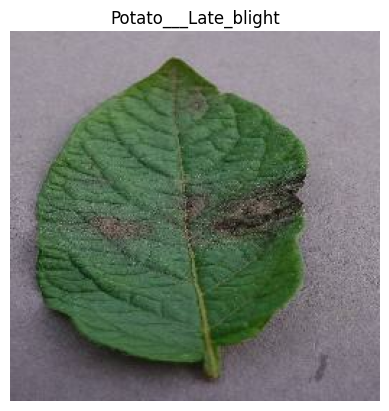

In [16]:
for image_batch, labels_batch in datast.take(1):
  for i in range(12):
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    # print(image_batch[i].shape)
    plt.title(class_names[labels_batch[i]])
    plt.axis("off")

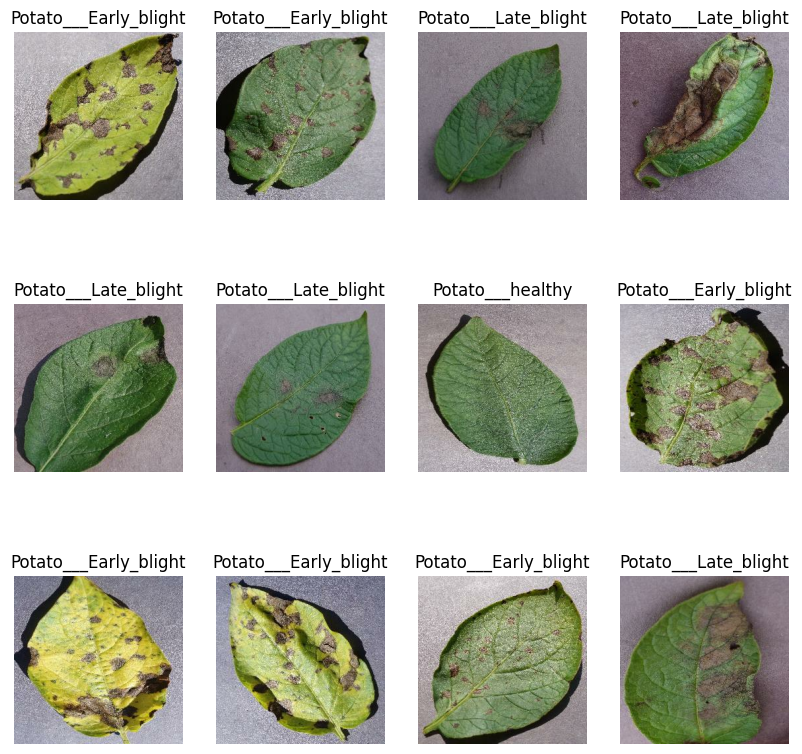

In [27]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in datast.take(1):
    for i in range(12):
      ax= plt.subplot(3, 4, i+1)
      plt.imshow(image_batch[i].numpy().astype("uint8"))
      plt.title(class_names[labels_batch[i]])
      plt.axis("off")

In [36]:
train_size= 0.8
len(datast)*train_size

48.0

In [37]:
train_ds= datast.take(48)
len(train_ds)

48

In [38]:
test_ds= datast.skip(48)
len(test_ds)

12

In [39]:
val_size= 0.1
len(datast)*val_size

6.0

In [40]:
val_ds= test_ds.take(6)
len(val_ds)

6

In [41]:
test_ds= test_ds.skip(6)
len(test_ds)

6

In [42]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size= len(ds)

    if shuffle:
        ds= ds.shuffle(shuffle_size, seed=12)

    train_size= int(train_split*ds_size)
    val_size= int(val_split*ds_size)

    train_ds= ds.take(train_size)

    val_ds= ds.skip(train_size).take(val_size)
    test_ds= ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [43]:
train_ds, val_ds, test_ds= get_dataset_partitions_tf(datast)

In [44]:
len(train_ds)

48

In [45]:
len(val_ds)

6

In [46]:
len(test_ds)

6

In [47]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds= val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds= test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [51]:
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(image_size, image_size),
    tf.keras.layers.Rescaling(1./255)
])

In [52]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
])

In [56]:
input_shape= (image_size, image_size, channel)
model= models.Sequential([
    tf.keras.Input(shape=input_shape),
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [57]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [59]:
histroy= model.fit(
    train_ds,
    batch_size=batch_size,
    validation_data=val_ds,
    verbose=1,
    epochs=50
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 247s 5s/step - accuracy: 0.5079 - loss: 0.9324 - val_accuracy: 0.6979 - val_loss: 0.8659
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 250s 5s/step - accuracy: 0.6928 - loss: 0.7902 - val_accuracy: 0.6771 - val_loss: 0.6965
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 281s 5s/step - accuracy: 0.8007 - loss: 0.4599 - val_accuracy: 0.7240 - val_loss: 0.5271
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 236s 5s/step - accuracy: 0.8250 - loss: 0.4105 - val_accuracy: 0.9010 - val_loss: 0.2661
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 217s 5s/step - accuracy: 0.8914 - loss: 0.2578 - val_accuracy: 0.8958 - val_loss: 0.2410
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 273s 5s/step - accuracy: 0.9013 - loss: 0.2496 - val_accuracy: 0.9375 - val_loss: 0.1588
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 218s 5s/step - accuracy: 0.9243 - loss: 0.2082 - val_accuracy: 0.9323 - val_loss: 0.1371
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 229s 5s/step - accuracy: 0.9276 - loss: 0.1832 - val_accuracy: 0.9219 - v

In [60]:
scores= model.evaluate(test_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9740 - loss: 0.0727


In [61]:
scores

[0.07272370904684067, 0.9739583134651184]

In [62]:
histroy

In [63]:
histroy.params

{'verbose': 1, 'epochs': 50, 'steps': 48}

In [64]:
histroy.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [66]:
acc= histroy.history['accuracy']
val_acc= histroy.history['val_accuracy']

loss= histroy.history['loss']
val_loss= histroy.history['val_loss']

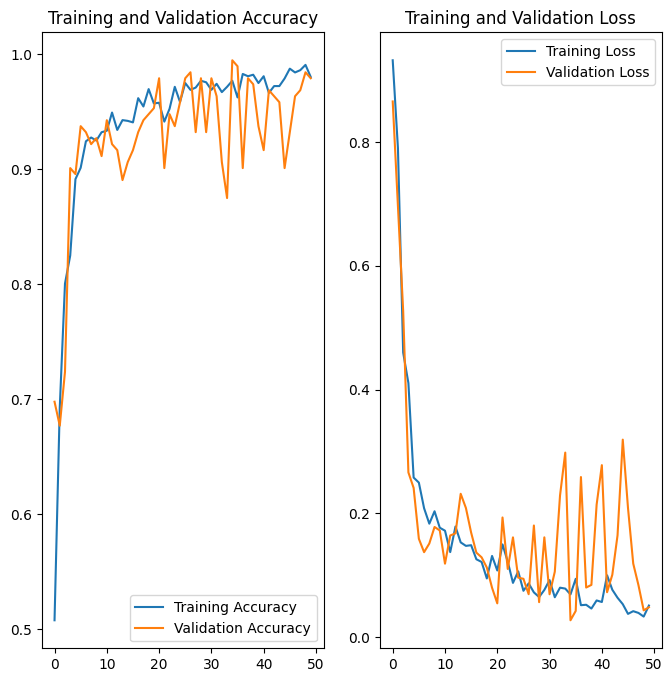

In [67]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(50), acc, label='Training Accuracy')
plt.plot(range(50), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(50), loss, label='Training Loss')
plt.plot(range(50), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted label: Potato___Late_blight


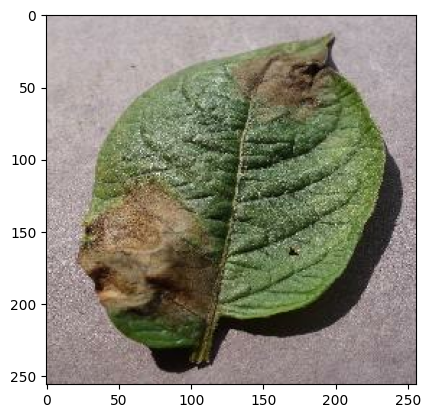

In [68]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
  first_image= images_batch[0].numpy().astype("uint8")
  first_label= labels_batch[0].numpy()

  print("first image to predict")
  plt.imshow(first_image)
  print("actual label:", class_names[first_label])

  batch_prediction= model.predict(images_batch)
  print("predicted label:", class_names[np.argmax(batch_prediction[0])])


In [69]:
def predict(model, img):
  img_array= tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array= tf.expand_dims(img_array, 0)

  predictions= model.predict(img_array)
  predicted_class= class_names[np.argmax(predictions[0])]
  confidence= round(100*(np.max(predictions[0])), 2)
  return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


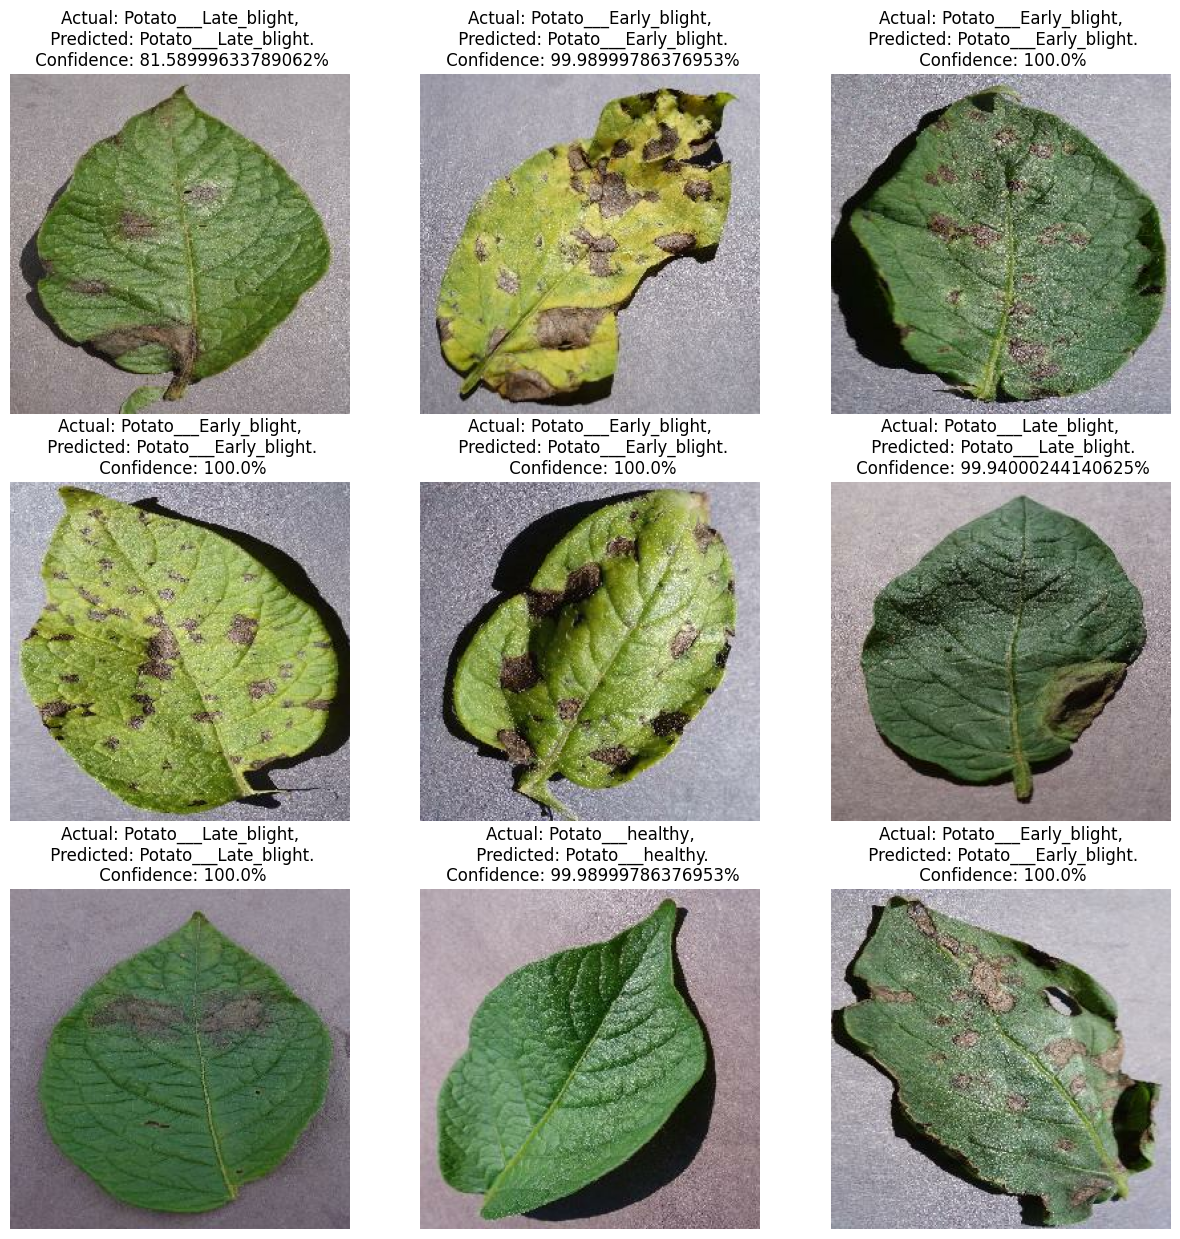

In [70]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
  for i in range(9):
    ax= plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class, confidence= predict(model, images[i].numpy())
    actual_class= class_names[labels[i]]

    plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
    plt.axis('off')

In [73]:
import os
if not os.path.exists('../models'):
    os.makedirs('../models')
model_version= max([int(i) for i in os.listdir('../models') + [0]])+1
model.save(f"../models/{model_version}.keras")

In [75]:
model_version= 1
model.save(f'../models/{model_version}.keras')

In [ ]:
from fastapi import FastAPI
from uvicorn

app= FastAPI()

@app.get('/ping')
async def ping():
  return "Hello, I am alive"

if __name__ == "__main__":
  uvicorn.run(app, host='localhost', port=8000)